# ECG Signal Preprocessing — MIT-BIH Arrhythmia Database
## Phase 1: Data Loading & Exploration

We're working with the MIT-BIH Arrhythmia Database:
- 48 half-hour recordings from 47 subjects
- 2 channels per record (usually MLII + V1/V2/V4/V5)
- Sampled at **360 Hz**, 11-bit resolution, 10 mV range
- ~110,000 annotated beats covering normal + ~15 arrhythmia types

In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from collections import Counter

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

### Loading a Record
Each record consists of 3 files: `.hea` (header/metadata), `.dat` (signal data), `.atr` (annotations).
We start with **record 100** — a relatively clean recording, good for establishing a baseline before we look at noisier ones.

In [4]:
DATA_PATH = r'E:\NU\Tasks\Offline Task 1\mit-bih-arrhythmia-database-1.0.0\mit-bih-arrhythmia-database-1.0.0'
record = wfdb.rdrecord(f'{DATA_PATH}/100')
annotation = wfdb.rdann(f'{DATA_PATH}/100', 'atr')

print(f"Signal names:      {record.sig_name}")
print(f"Sampling freq:     {record.fs} Hz")
print(f"Total samples:     {record.sig_len}")
print(f"Duration:          {record.sig_len / record.fs:.1f} sec ({record.sig_len / record.fs / 60:.1f} min)")
print(f"Signal shape:      {record.p_signal.shape}")
print(f"Units:             {record.units}")
print(f"ADC resolution:    {record.adc_res}")
print(f"\nBeat annotations:  {len(annotation.symbol)} total")
print(f"Beat types:")
for sym, count in Counter(annotation.symbol).most_common():
    print(f"  {sym}: {count}")

Signal names:      ['MLII', 'V5']
Sampling freq:     360 Hz
Total samples:     650000
Duration:          1805.6 sec (30.1 min)
Signal shape:      (650000, 2)
Units:             ['mV', 'mV']
ADC resolution:    [11, 11]

Beat annotations:  2274 total
Beat types:
  N: 2239
  A: 33
  +: 1
  V: 1


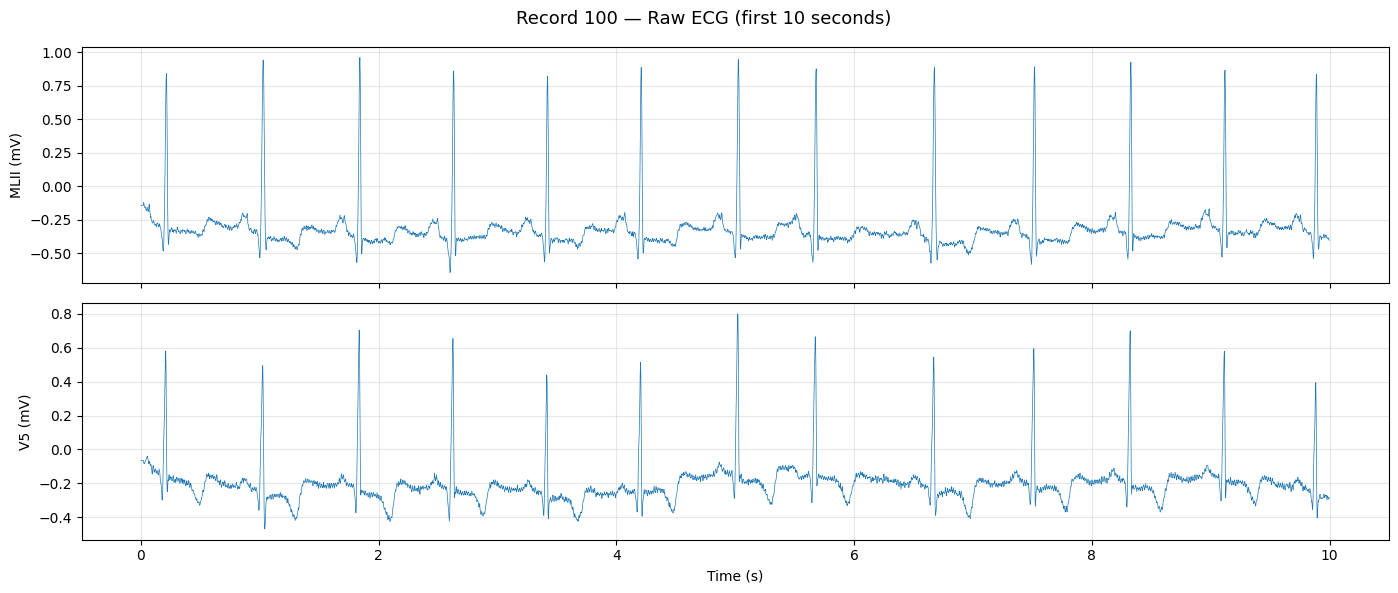

In [5]:
fs = record.fs
ecg = record.p_signal  # shape: (samples, 2)
t = np.arange(len(ecg)) / fs  # time axis in seconds

# Plot first 10 seconds of both channels
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for i, name in enumerate(record.sig_name):
    axes[i].plot(t[:10*fs], ecg[:10*fs, i], linewidth=0.5)
    axes[i].set_ylabel(f'{name} (mV)')
    axes[i].grid(True, alpha=0.3)

axes[1].set_xlabel('Time (s)')
fig.suptitle('Record 100 — Raw ECG (first 10 seconds)', fontsize=13)
plt.tight_layout()
plt.show()

### Frequency Analysis (FFT)
Before filtering, we need to **see** what noise is present. The FFT converts the signal from time → frequency domain, 
showing us which frequencies have energy. We expect to see:
- **0–0.5 Hz**: Baseline wander (breathing, movement)
- **10–50 Hz**: QRS energy (the useful stuff)
- **50 Hz (Egypt) / 60 Hz (US)**: Power-line interference spike
- **>100 Hz**: Muscle noise, high-frequency artifacts

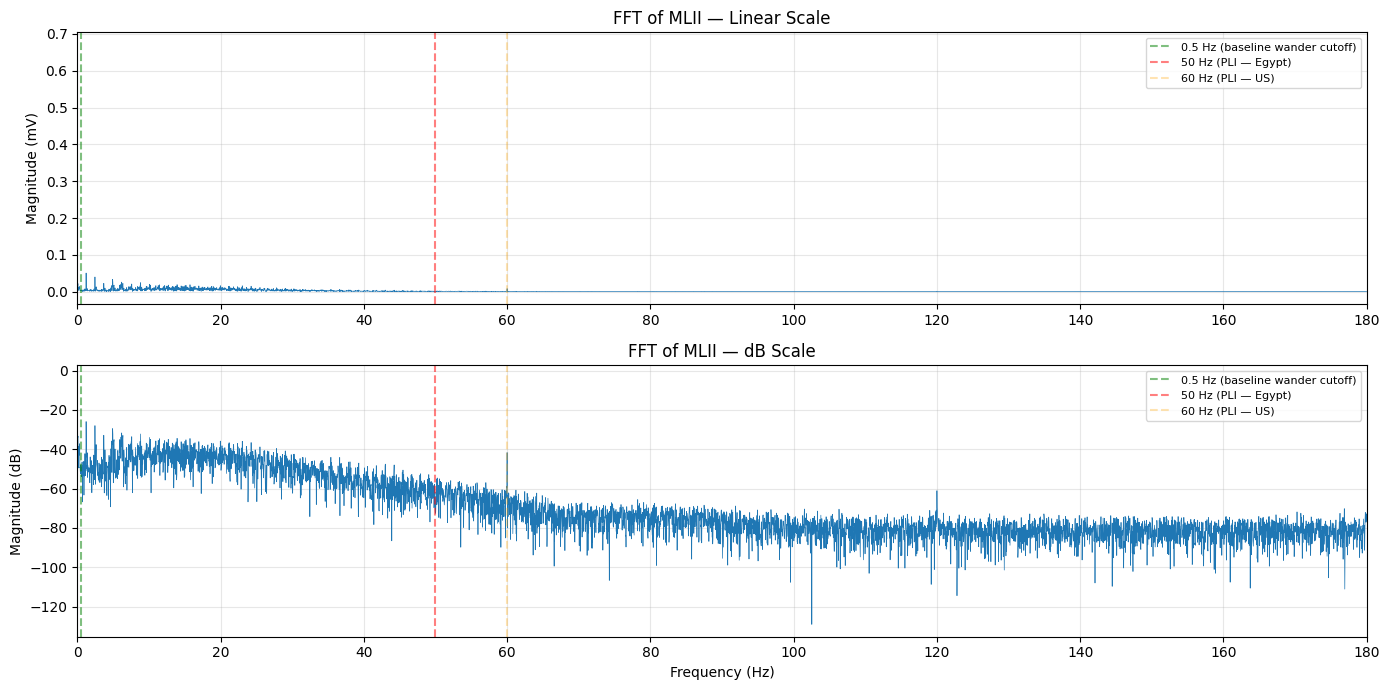

In [6]:
# We'll analyze the MLII channel (channel 0) — the primary lead
ecg_mlii = ecg[:, 0]

# Compute FFT on first 30 seconds (enough to see frequency content clearly)
segment = ecg_mlii[:30 * fs]
N = len(segment)

yf = fft(segment)
xf = fftfreq(N, 1/fs)  # frequency axis

# Only positive frequencies, convert to magnitude in dB
pos_mask = xf >= 0
freqs = xf[pos_mask]
magnitude = 2.0 / N * np.abs(yf[pos_mask])
magnitude_db = 20 * np.log10(magnitude + 1e-12)  # dB scale, avoid log(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Linear scale — see the dominant peaks
axes[0].plot(freqs, magnitude, linewidth=0.5)
axes[0].set_xlim(0, 180)
axes[0].set_ylabel('Magnitude (mV)')
axes[0].set_title('FFT of MLII — Linear Scale')
axes[0].grid(True, alpha=0.3)

# dB scale — see the noise floor
axes[1].plot(freqs, magnitude_db, linewidth=0.5)
axes[1].set_xlim(0, 180)
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_title('FFT of MLII — dB Scale')
axes[1].grid(True, alpha=0.3)

# Mark important frequencies
for ax in axes:
    ax.axvline(0.5, color='green', linestyle='--', alpha=0.5, label='0.5 Hz (baseline wander cutoff)')
    ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50 Hz (PLI — Egypt)')
    ax.axvline(60, color='orange', linestyle='--', alpha=0.3, label='60 Hz (PLI — US)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Zoom into Low Frequencies
Let's zoom into 0–5 Hz to check for baseline wander, and around 50 Hz to check for power-line interference.

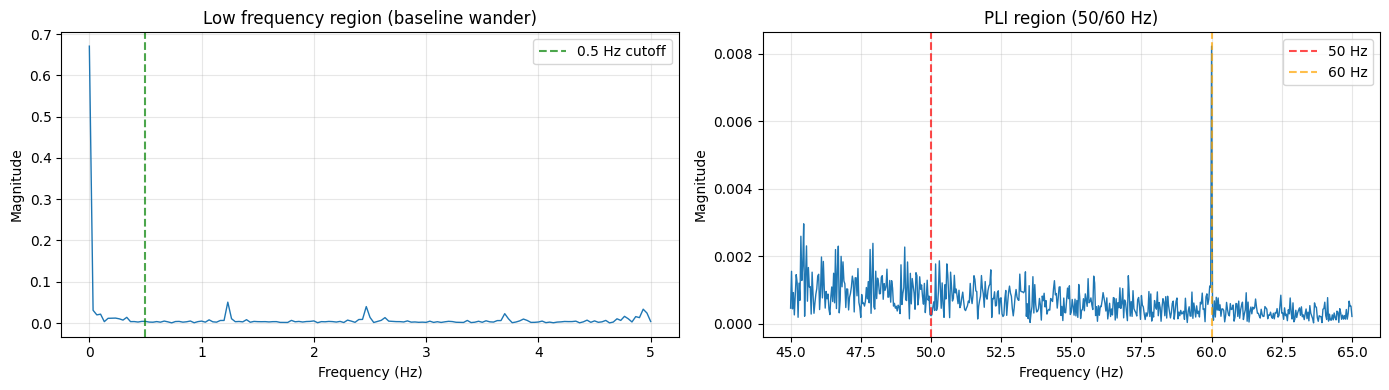

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Zoom: 0–5 Hz (baseline wander region)
mask_low = freqs <= 5
axes[0].plot(freqs[mask_low], magnitude[mask_low], linewidth=1)
axes[0].axvline(0.5, color='green', linestyle='--', alpha=0.7, label='0.5 Hz cutoff')
axes[0].set_title('Low frequency region (baseline wander)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom: 45–65 Hz (PLI region)
mask_pli = (freqs >= 45) & (freqs <= 65)
axes[1].plot(freqs[mask_pli], magnitude[mask_pli], linewidth=1)
axes[1].axvline(50, color='red', linestyle='--', alpha=0.7, label='50 Hz')
axes[1].axvline(60, color='orange', linestyle='--', alpha=0.7, label='60 Hz')
axes[1].set_title('PLI region (50/60 Hz)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
print("=== MLII Channel Statistics ===")
print(f"Mean:     {ecg_mlii.mean():.4f} mV")
print(f"Std Dev:  {ecg_mlii.std():.4f} mV")
print(f"Min:      {ecg_mlii.min():.4f} mV")
print(f"Max:      {ecg_mlii.max():.4f} mV")
print(f"Range:    {ecg_mlii.max() - ecg_mlii.min():.4f} mV")

# Rough SNR estimate (from the paper's formula)
snr_estimate = 20 * np.log10((ecg_mlii.max() - ecg_mlii.min()) / ecg_mlii.std())
print(f"\nSNR estimate: {snr_estimate:.2f} dB")

=== MLII Channel Statistics ===
Mean:     -0.3063 mV
Std Dev:  0.1932 mV
Min:      -2.7150 mV
Max:      1.4350 mV
Range:    4.1500 mV

SNR estimate: 26.64 dB


## Phase 2: Filtering Techniques

We'll work on the MLII channel and apply filters from simple to advanced.
For each filter we'll:
1. Explain the intuition
2. Apply it
3. Plot before vs after (time domain)
4. Plot the FFT before vs after (frequency domain)
5. Compute quality metrics

### Helper Functions

In [11]:
def compute_metrics(original, filtered):
    """Compute signal quality metrics between original and filtered signal."""
    mse = np.mean((original - filtered) ** 2)
    rmse = np.sqrt(mse)
    
    # PRD — Percent Root-mean-square Difference
    prd = 100 * np.sqrt(np.sum((original - filtered)**2) / np.sum(original**2))
    
    # Correlation coefficient
    corr = np.corrcoef(original, filtered)[0, 1]
    
    # SNR of filtered signal (using the paper's heuristic formula)
    sig_range = filtered.max() - filtered.min()
    snr = 20 * np.log10(sig_range / (filtered.std() + 1e-12))
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'PRD (%)': prd,
        'Correlation': corr,
        'SNR (dB)': snr
    }


def plot_filter_result(t, original, filtered, title, fs, zoom_start=2, zoom_dur=3):
    """Plot before/after in time domain + FFT comparison."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Full 10-second view
    end = min(10 * fs, len(original))
    axes[0].plot(t[:end], original[:end], alpha=0.5, linewidth=0.5, label='Original')
    axes[0].plot(t[:end], filtered[:end], linewidth=0.7, label='Filtered')
    axes[0].set_title(f'{title} — Full View (10s)')
    axes[0].set_ylabel('Amplitude (mV)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Zoomed view (2-3 beats)
    z_start = int(zoom_start * fs)
    z_end = int((zoom_start + zoom_dur) * fs)
    axes[1].plot(t[z_start:z_end], original[z_start:z_end], alpha=0.5, linewidth=1, label='Original')
    axes[1].plot(t[z_start:z_end], filtered[z_start:z_end], linewidth=1, label='Filtered')
    axes[1].set_title(f'{title} — Zoomed ({zoom_start}–{zoom_start+zoom_dur}s)')
    axes[1].set_ylabel('Amplitude (mV)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # FFT comparison
    N = len(original)
    freq = fftfreq(N, 1/fs)
    pos = freq >= 0
    
    mag_orig = 2.0/N * np.abs(fft(original))[pos]
    mag_filt = 2.0/N * np.abs(fft(filtered))[pos]
    
    axes[2].plot(freq[pos], 20*np.log10(mag_orig + 1e-12), alpha=0.5, linewidth=0.5, label='Original')
    axes[2].plot(freq[pos], 20*np.log10(mag_filt + 1e-12), linewidth=0.5, label='Filtered')
    axes[2].set_xlim(0, 100)
    axes[2].set_title(f'{title} — FFT Comparison')
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Magnitude (dB)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    metrics = compute_metrics(original, filtered)
    print(f"\n📊 Metrics for {title}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")

### Filter 1: High-Pass Filter (Butterworth) — Removing Baseline Wander

**What it does:** Removes all frequencies below a cutoff (0.5 Hz), eliminating the slow drift 
caused by breathing and patient movement.

**Why Butterworth?** It has the flattest possible passband — meaning it doesn't add ripples or 
distortion to the frequencies we want to keep. "Maximally flat magnitude" is its defining feature.

**Why `filtfilt`?** Normal filtering shifts the signal in time (phase distortion). `filtfilt` applies 
the filter forward AND backward, canceling the phase shift — critical for ECG where timing between 
P, QRS, and T waves matters clinically.

**Parameters (from the paper):**
- Cutoff: 0.5 Hz (preserves P wave at 0.67 Hz)
- Order: 4 (good sharpness without ringing)

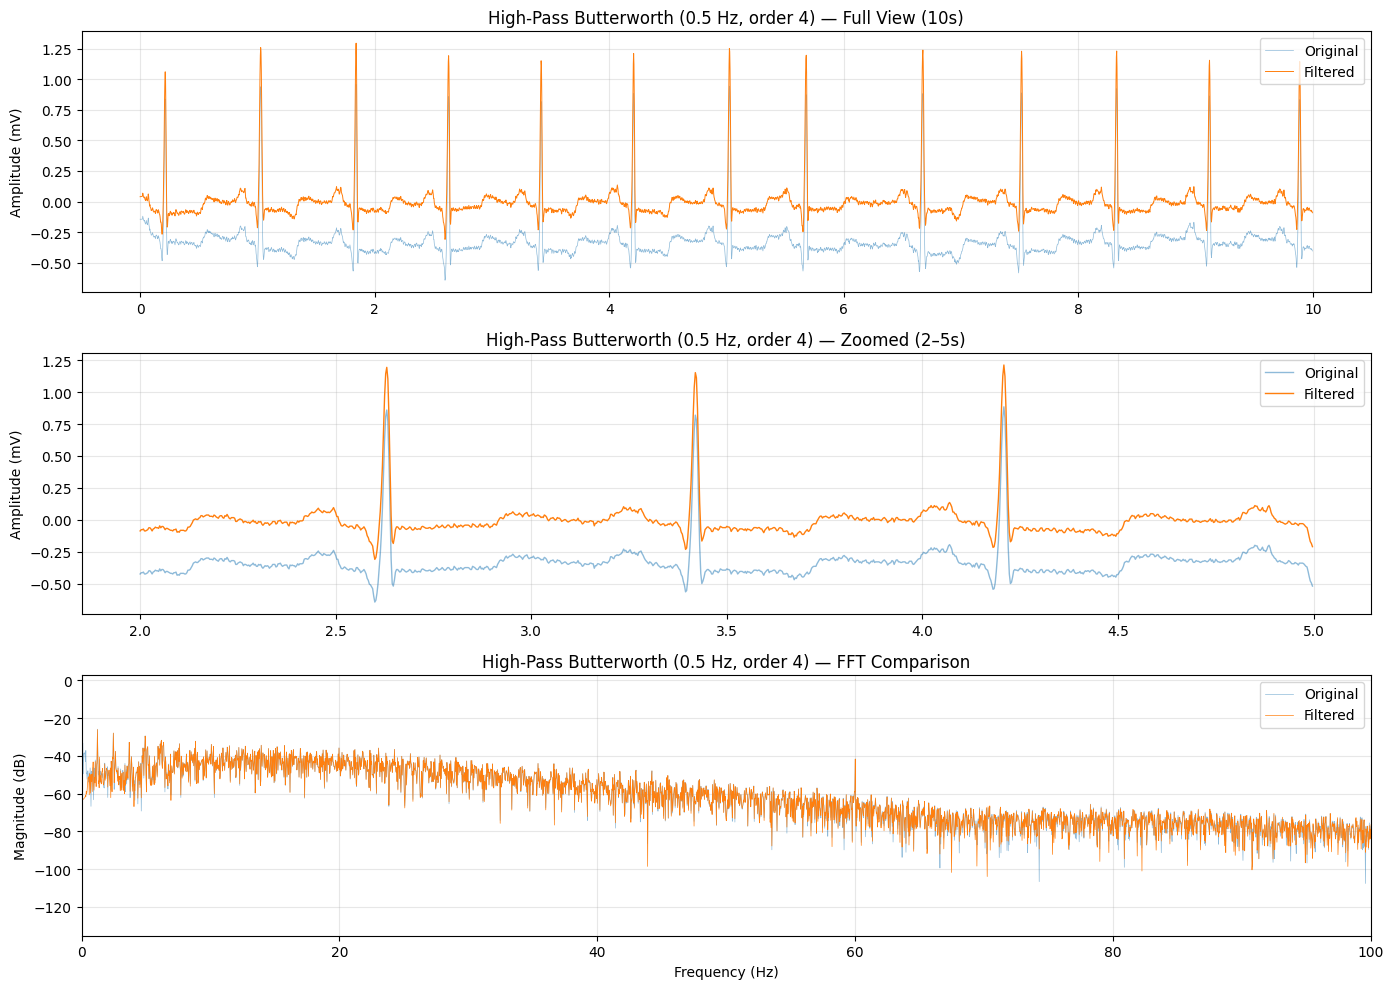


📊 Metrics for High-Pass Butterworth (0.5 Hz, order 4):
  MSE: 0.113720
  RMSE: 0.337224
  PRD (%): 89.288758
  Correlation: 0.975254
  SNR (dB): 20.167796


In [12]:
# Work on first 30 seconds for clear visualization
duration = 30  # seconds
seg = ecg_mlii[:duration * fs].copy()
t_seg = t[:duration * fs]

# Design high-pass Butterworth filter
cutoff_hp = 0.5       # Hz
order_hp = 4
sos_hp = signal.butter(order_hp, cutoff_hp, btype='highpass', fs=fs, output='sos')

# Apply zero-phase filtering
ecg_hp = signal.sosfiltfilt(sos_hp, seg)

# Plot results
plot_filter_result(t_seg, seg, ecg_hp, 'High-Pass Butterworth (0.5 Hz, order 4)', fs)

### Filter 2: Notch Filter — Removing Power-Line Interference

**What it does:** Surgically removes a very narrow band of frequencies around a target (50 or 60 Hz) 
while leaving everything else untouched. Think of it as poking a tiny hole in the frequency spectrum.

**Why a notch?** PLI is a single-frequency sinusoidal contamination. A broadband filter (like low-pass) 
would kill useful QRS energy in that range too. The notch is a scalpel, not a sledgehammer.

**Note:** Our FFT showed minimal PLI in record 100 (the hardware already filtered it). We'll apply it 
anyway for completeness — and because other records or real-world signals WILL have PLI. Since this 
was recorded in the US, we target 60 Hz. In Egypt you'd target 50 Hz.

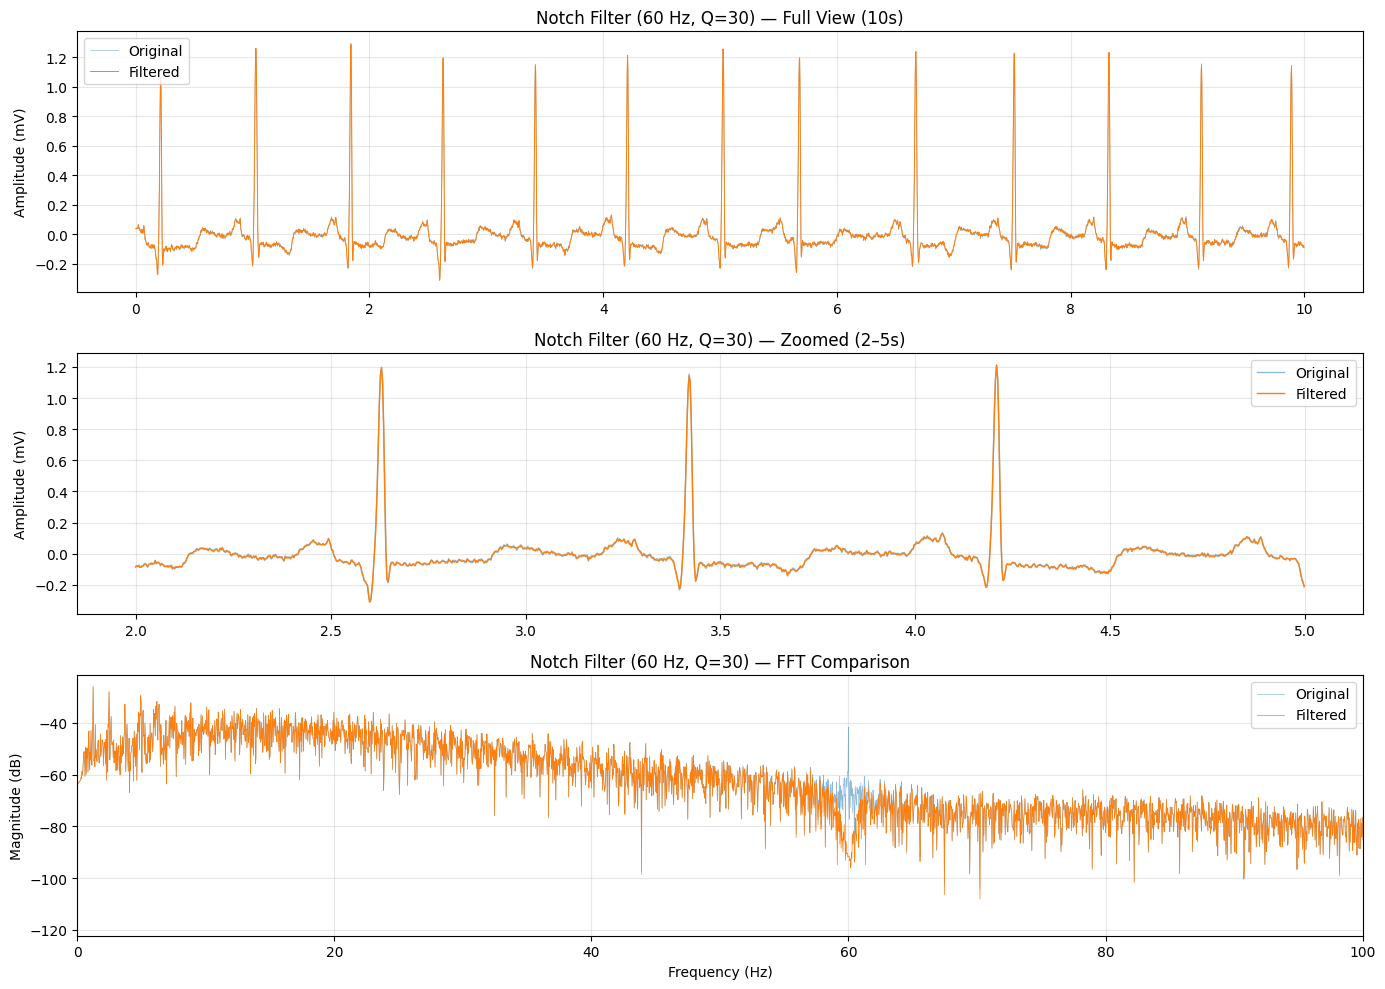


📊 Metrics for Notch Filter (60 Hz, Q=30):
  MSE: 0.000040
  RMSE: 0.006323
  PRD (%): 3.728383
  Correlation: 0.999305
  SNR (dB): 20.176804


In [13]:
# Apply notch on TOP of the high-pass filtered signal (cascading filters)
f_notch = 60.0       # 60 Hz for MIT-BIH (US recording). Use 50.0 for Egypt
Q = 30.0             # Quality factor — higher = narrower notch

b_notch, a_notch = signal.iirnotch(f_notch, Q, fs)
ecg_notch = signal.filtfilt(b_notch, a_notch, ecg_hp)

plot_filter_result(t_seg, ecg_hp, ecg_notch, 'Notch Filter (60 Hz, Q=30)', fs)

### Filter 3: Moving Average — Simple Smoothing

**What it does:** Replaces each sample with the average of its neighbors within a sliding window. 
The simplest possible smoother — like blurring a photo to remove grain.

**Intuition:** If noise is random (equally likely positive or negative), averaging nearby samples 
cancels it out. But it also blunts sharp transitions — the R peak will get shorter.

**Window size matters:**
- Too small (5 samples) → barely smooths anything
- Too large (100 samples) → destroys the QRS complex
- Sweet spot: ~20 samples (≈55 ms at 360 Hz) — preserves QRS while smoothing noise

The paper found 20 samples optimal for QRS detection tasks.

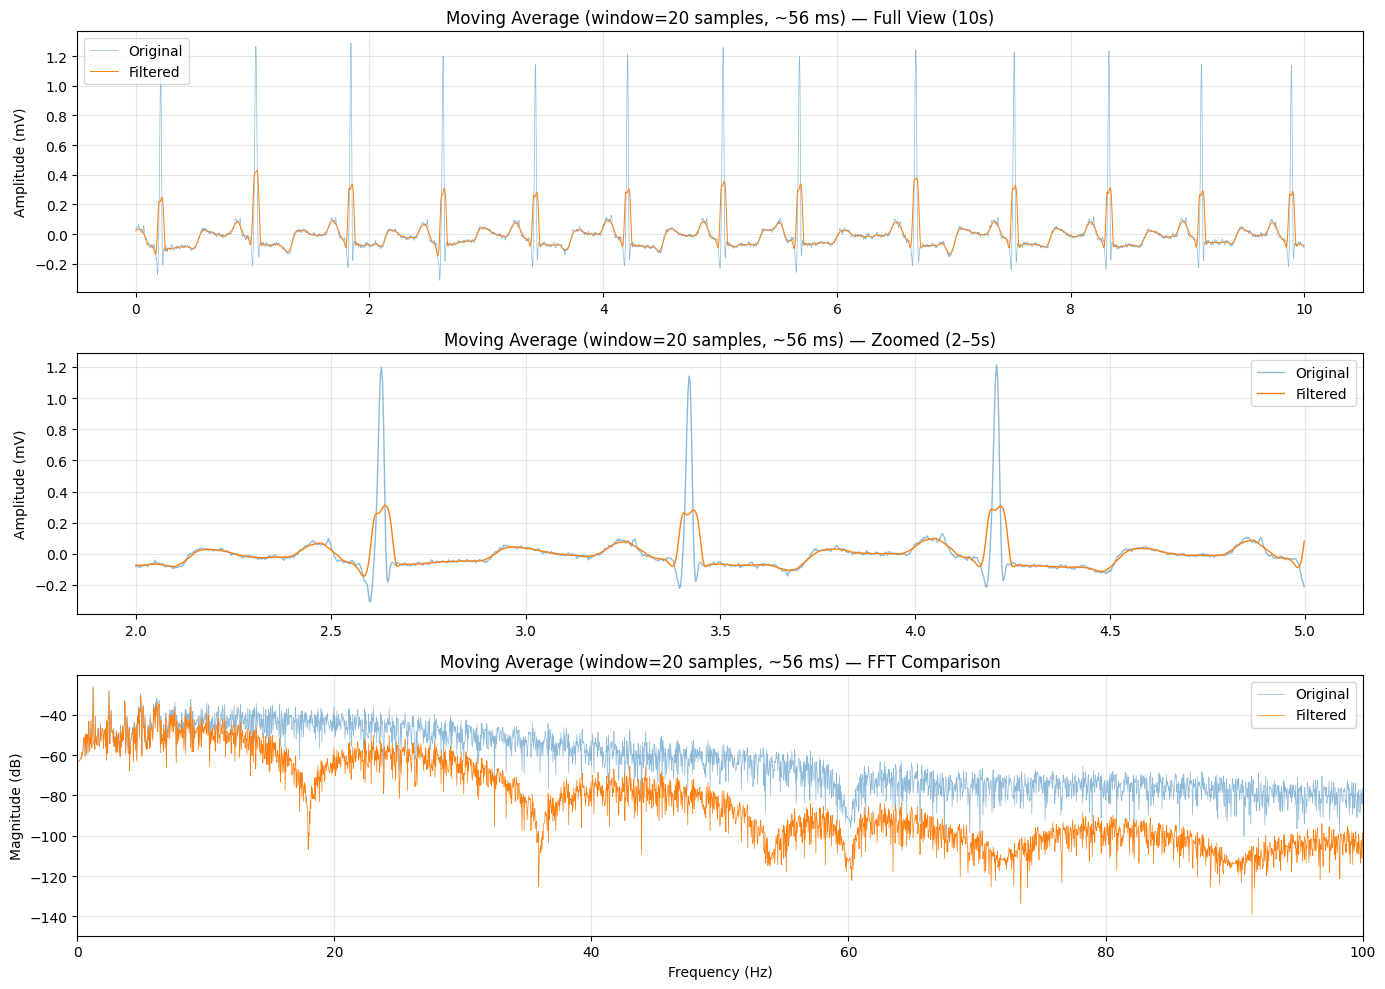


📊 Metrics for Moving Average (window=20 samples, ~56 ms):
  MSE: 0.016409
  RMSE: 0.128096
  PRD (%): 75.615927
  Correlation: 0.663092
  SNR (dB): 16.926056


In [14]:
# Apply MA on the notch-filtered signal (cascading)
window_size = 20  # ~55 ms at 360 Hz

# Moving average using convolution
kernel = np.ones(window_size) / window_size
ecg_ma = np.convolve(ecg_notch, kernel, mode='same')

plot_filter_result(t_seg, ecg_notch, ecg_ma, f'Moving Average (window={window_size} samples, ~{1000*window_size/fs:.0f} ms)', fs)

### Filter 4: Savitzky-Golay (SGS) — Smart Smoothing

**The problem with MA:** It fits a flat line (average) to each window. Flat lines can't 
follow sharp peaks → peaks get crushed.

**SGS solution:** Instead of fitting a flat average, fit a **polynomial** to each window. 
A polynomial can curve, so it follows the R peak's shape much better while still smoothing 
out random noise. It's like tracing over a noisy drawing with a smooth curved pen instead of 
a straight ruler.

**Two parameters:**
- `window_length`: how many samples to fit over (must be odd). Similar tradeoff as MA.
- `polyorder`: degree of polynomial. Higher = follows the signal more closely but smooths less.

The paper found SGS particularly suitable for high-precision ECG analysis.

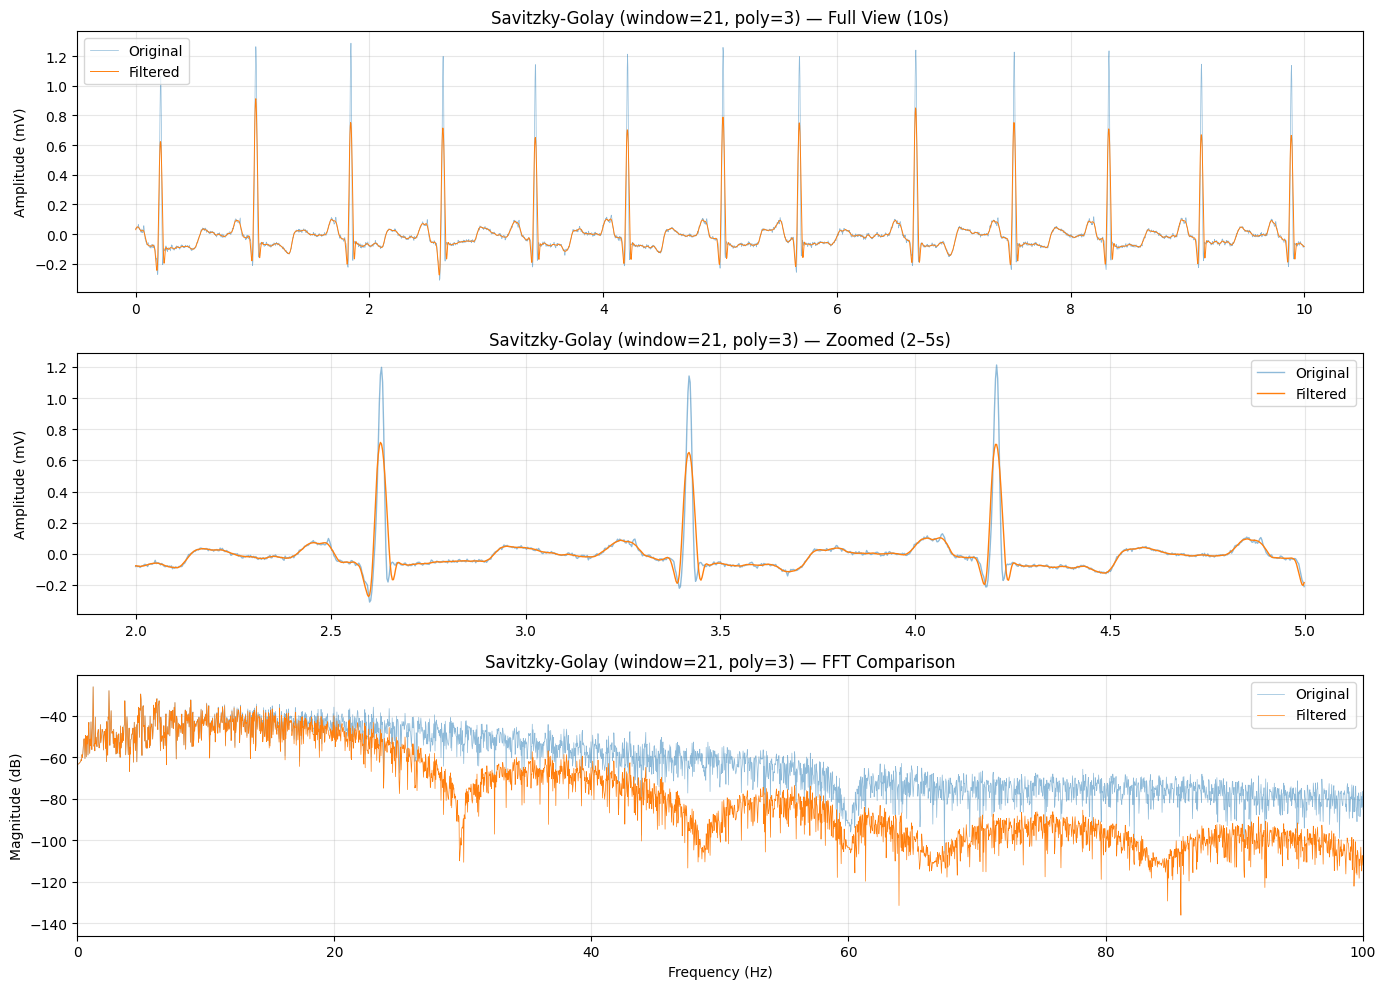


📊 Metrics for Savitzky-Golay (window=21, poly=3):
  MSE: 0.004603
  RMSE: 0.067843
  PRD (%): 40.048427
  Correlation: 0.921230
  SNR (dB): 19.367597


In [15]:
# Apply SGS on the notch-filtered signal (NOT on MA — we're comparing independently)
window_sgs = 21   # must be odd, ~58 ms at 360 Hz
poly_order = 3    # cubic polynomial — good balance

ecg_sgs = signal.savgol_filter(ecg_notch, window_length=window_sgs, polyorder=poly_order)

plot_filter_result(t_seg, ecg_notch, ecg_sgs, f'Savitzky-Golay (window={window_sgs}, poly={poly_order})', fs)

### Filter 5: Chebyshev Type II Bandpass — Precise Frequency Selection

**What it does:** Passes only a specific frequency range (e.g., 0.5–40 Hz) and sharply 
rejects everything outside. Unlike Butterworth which rolls off gently, Chebyshev Type II has 
a much steeper transition — it goes from "pass" to "block" much faster.

**Why Type II (not Type I)?**
- Type I has ripples in the **passband** (distorts the frequencies you want to keep)
- Type II has ripples in the **stopband** (distorts only the frequencies you're throwing away)

For ECG, we want a clean passband → Type II is the better choice.

**Parameters:**
- Passband: 0.5–40 Hz (covers all ECG components: P, QRS, T)
- Stopband attenuation: 40 dB (how aggressively it kills out-of-band noise)

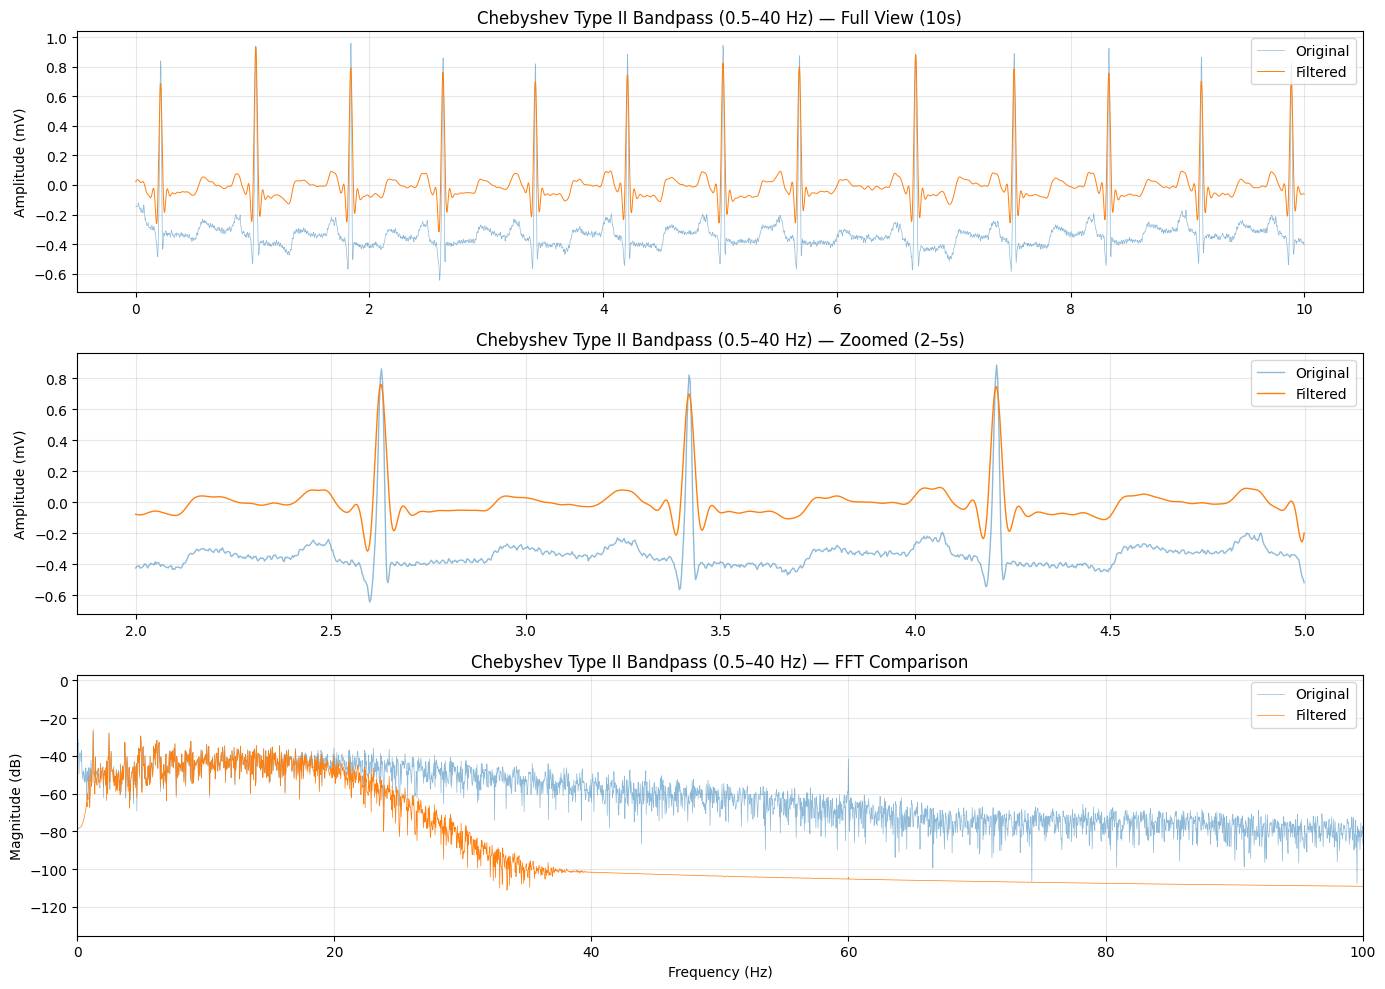


📊 Metrics for Chebyshev Type II Bandpass (0.5–40 Hz):
  MSE: 0.118480
  RMSE: 0.344210
  PRD (%): 91.138288
  Correlation: 0.895926
  SNR (dB): 19.600920


In [16]:
# Chebyshev Type II bandpass
low_cut = 0.5     # Hz
high_cut = 40.0   # Hz
rs = 40           # stopband attenuation in dB
order_cheb = 4

sos_cheb = signal.cheby2(order_cheb, rs, [low_cut, high_cut], btype='bandpass', fs=fs, output='sos')
ecg_cheb = signal.sosfiltfilt(sos_cheb, seg)  # apply on original segment (not cascaded)

plot_filter_result(t_seg, seg, ecg_cheb, 'Chebyshev Type II Bandpass (0.5–40 Hz)', fs)

### Observations — SGS vs MA vs Chebyshev
Compare the correlation values:
- **MA**: smooths but destroys peaks (low correlation)
- **SGS**: smooths while preserving peaks (should have higher correlation)
- **Chebyshev II**: defines exact frequency boundaries (handles both baseline wander AND high-freq noise)

The Chebyshev is essentially doing what the high-pass + notch did, but in one step and more aggressively 
cutting everything above 40 Hz too.

## Phase 3: Advanced Filters

### Filter 6: Stationary Wavelet Transform (SWT) — The Paper's Winner 🏆

**The key idea:** Wavelets decompose a signal into different frequency "layers" (called detail 
coefficients at each level). Low levels capture high-frequency content (noise), high levels capture 
low-frequency content (baseline wander). The actual ECG features live in the middle levels.

**How it denoises:**
1. Decompose the signal into levels (like peeling an onion)
2. Apply soft thresholding to the detail coefficients — small coefficients (noise) get zeroed out, 
   large ones (real signal features) are kept
3. Reconstruct the signal from the cleaned coefficients

**Why SWT over DWT?**
- DWT (Discrete Wavelet Transform) downsamples at each level → shift-variant (shifting input by 
  1 sample gives different output). This can create artifacts.
- SWT skips the downsampling → shift-invariant, better feature preservation. Costs more computation 
  but worth it for ECG.

**Optimal parameters from the paper:**
- Wavelet: `rbio3.9` (reverse biorthogonal 3.9)
- Decomposition level: 5
- Threshold scale: 0.5

Estimated noise σ: 0.008478
Threshold: 0.018271


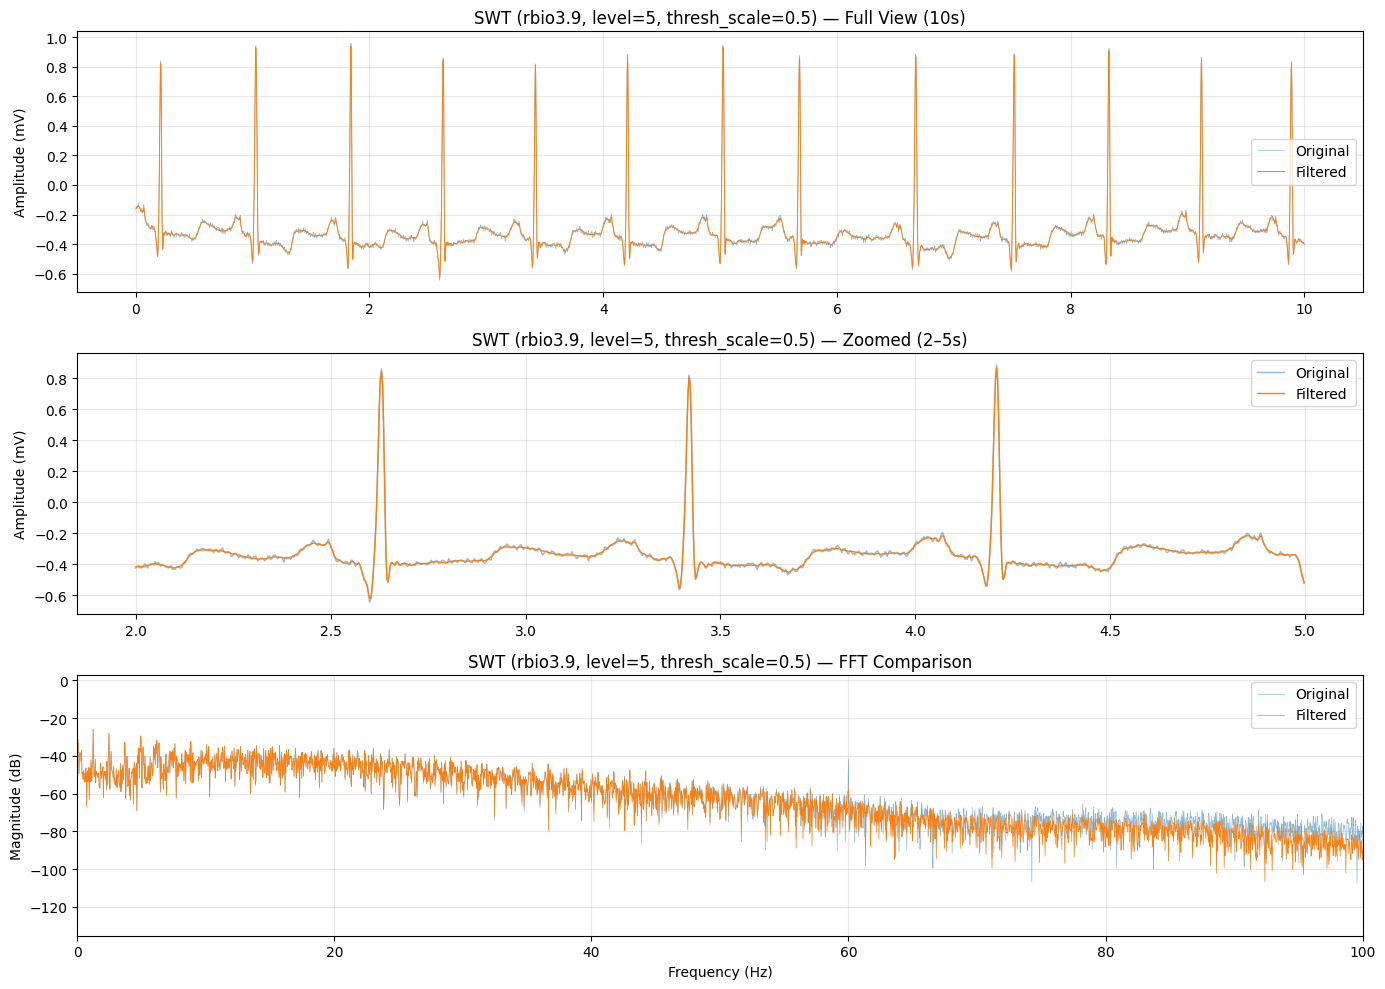


📊 Metrics for SWT (rbio3.9, level=5, thresh_scale=0.5):
  MSE: 0.000073
  RMSE: 0.008531
  PRD (%): 2.258853
  Correlation: 0.998878
  SNR (dB): 19.973564


In [ ]:
import pywt

# SWT requires signal length to be divisible by 2^level
level = 5
wavelet = ' rbio3.9'
threshold_scale = 0.5

# Pad signal to required length
pad_len = int(np.ceil(len(seg) / (2**level))) * (2**level) - len(seg)
ecg_padded = np.pad(seg, (0, pad_len), mode='symmetric')

# Decompose
coeffs = pywt.swt(ecg_padded, wavelet, level=level)

# Apply soft thresholding to detail coefficients
# Universal threshold: sigma * sqrt(2 * log(N))
# Estimate noise sigma from finest detail coefficients (level 1)
sigma = np.median(np.abs(coeffs[-1][1])) / 0.6745  # MAD estimator
threshold = threshold_scale * sigma * np.sqrt(2 * np.log(len(ecg_padded)))

print(f"Estimated noise σ: {sigma:.6f}")
print(f"Threshold: {threshold:.6f}")

coeffs_thresh = []
for (cA, cD) in coeffs:
    cD_thresh = pywt.threshold(cD, threshold, mode='soft')
    coeffs_thresh.append((cA, cD_thresh))

# Reconstruct
ecg_swt = pywt.iswt(coeffs_thresh, wavelet)
ecg_swt = ecg_swt[:len(seg)]  # remove padding

plot_filter_result(t_seg, seg, ecg_swt, f'SWT ({wavelet}, level={level}, thresh_scale={threshold_scale})', fs)

### Filter 7: Empirical Mode Decomposition (EMD) — Data-Driven Decomposition

**How it's different:** Unlike wavelets (which use predefined mathematical basis functions), 
EMD derives its decomposition entirely from the data itself. It peels the signal into 
Intrinsic Mode Functions (IMFs) — oscillatory components ordered from highest to lowest frequency.

**Denoising approach:**
- First few IMFs = high-frequency noise
- Middle IMFs = actual ECG (P, QRS, T)
- Last IMFs + residual = baseline wander
- We reconstruct using only the "good" middle IMFs

**Weakness:** Mode mixing — sometimes signal and noise bleed into the same IMF. 
The paper found EMD effective but with occasional outlier failures (PRD > 100%).

Number of IMFs: 16


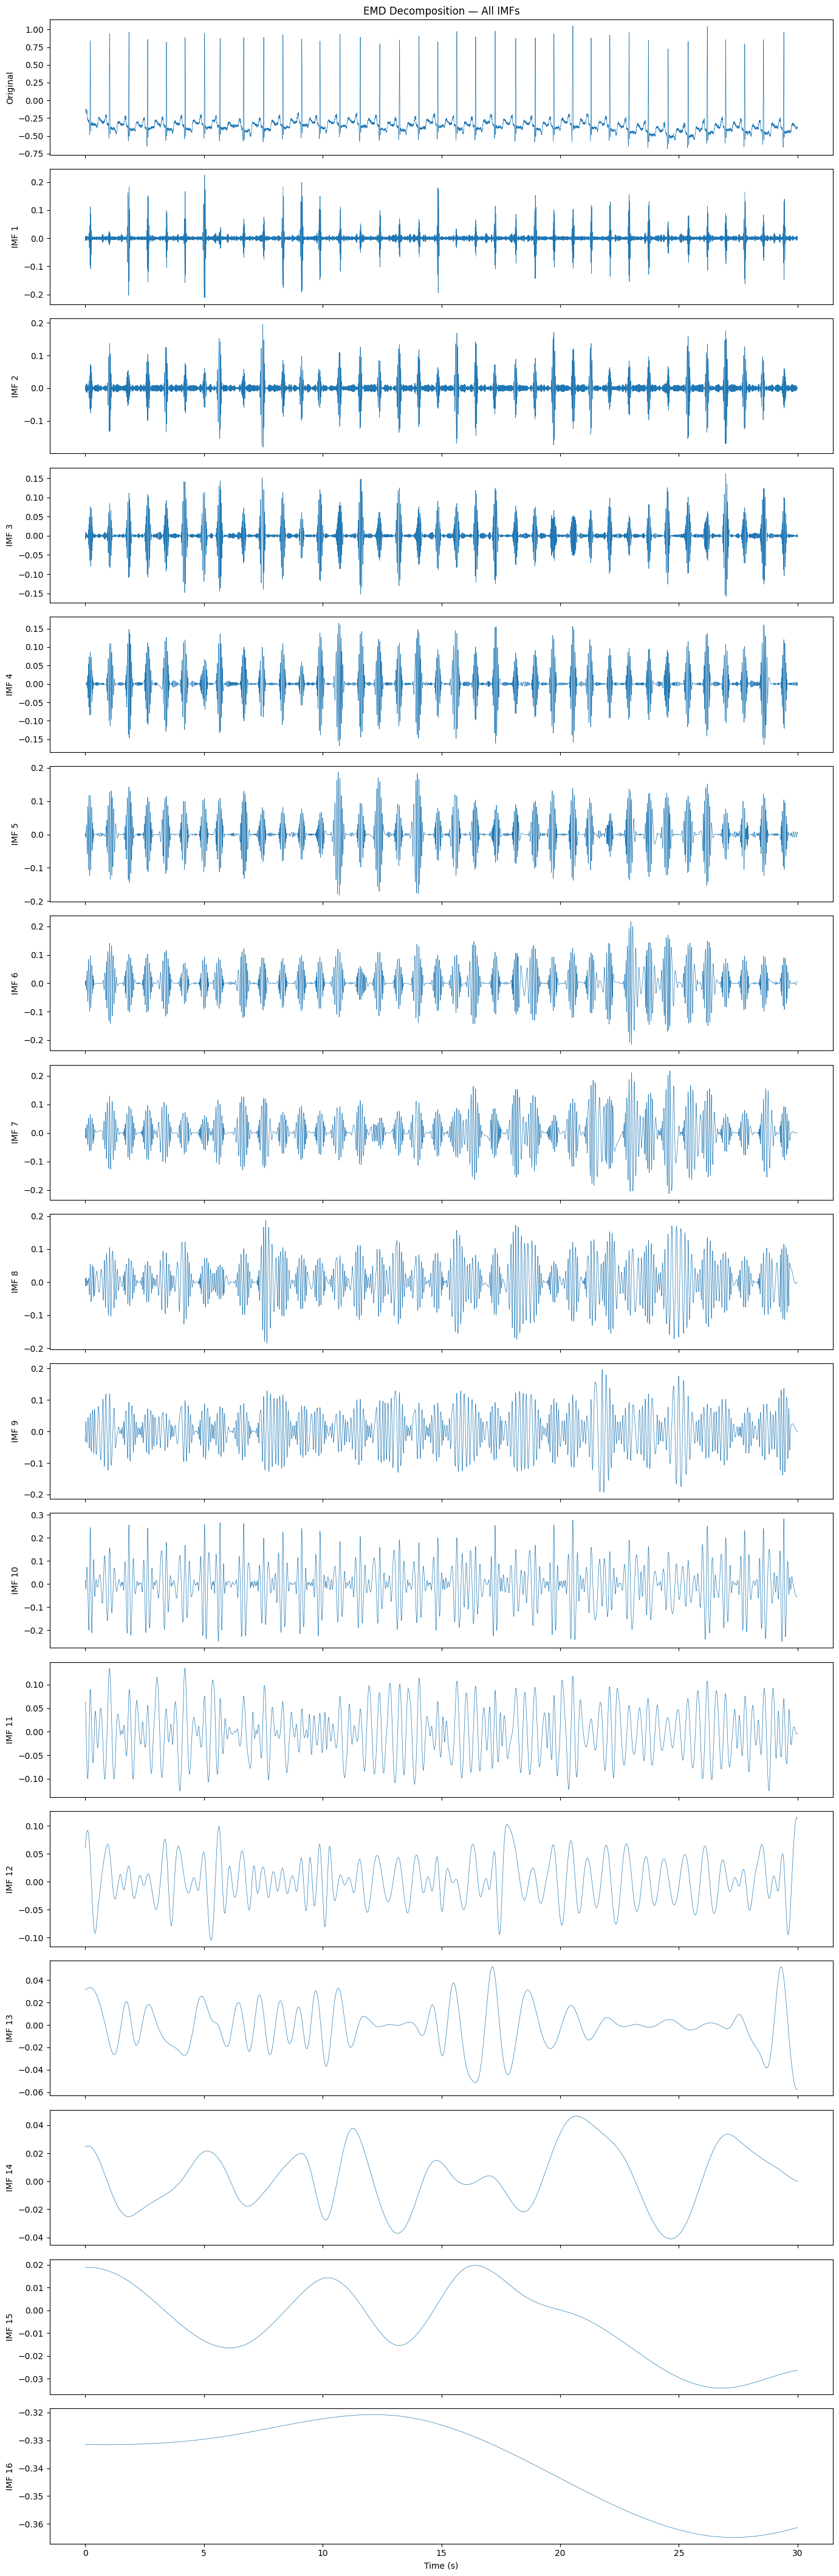

In [20]:
from PyEMD import EMD

emd = EMD()
IMFs = emd(seg)

print(f"Number of IMFs: {len(IMFs)}")

# Plot all IMFs to see what each one captured
fig, axes = plt.subplots(len(IMFs) + 1, 1, figsize=(14, 2.5 * (len(IMFs) + 1)), sharex=True)

axes[0].plot(t_seg, seg, linewidth=0.5)
axes[0].set_ylabel('Original')
axes[0].set_title('EMD Decomposition — All IMFs')

for i, imf in enumerate(IMFs):
    axes[i+1].plot(t_seg, imf, linewidth=0.5)
    axes[i+1].set_ylabel(f'IMF {i+1}')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

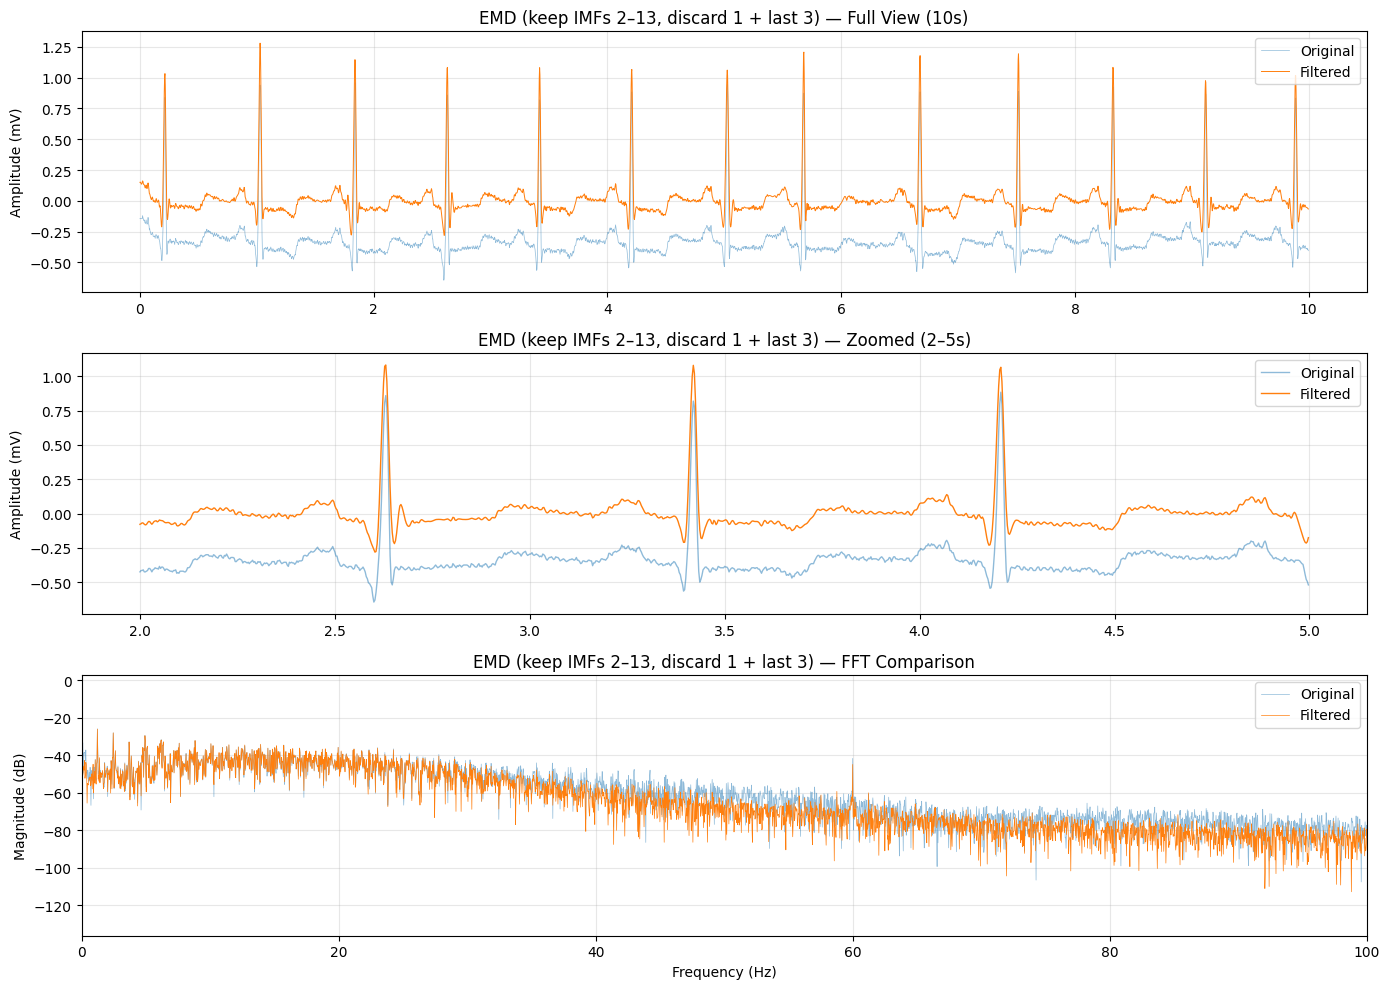


📊 Metrics for EMD (keep IMFs 2–13, discard 1 + last 3):
  MSE: 0.118341
  RMSE: 0.344007
  PRD (%): 91.084539
  Correlation: 0.970201
  SNR (dB): 20.079277


In [21]:
# Reconstruct by summing selected IMFs
# Skip IMF 1 (noise) and last 3 (baseline wander + DC)
# Keep IMFs 2 through 13

ecg_emd = np.sum(IMFs[1:-3], axis=0)

plot_filter_result(t_seg, seg, ecg_emd, 'EMD (keep IMFs 2–13, discard 1 + last 3)', fs)

## Phase 4: Final Comparison

### Summary of All Filters
Let's compare every filter side-by-side — both numerically and visually on the same ECG segment.

In [38]:
import pandas as pd

results = {
    'High-Pass Butterworth': compute_metrics(seg, ecg_hp),
    'Notch (60 Hz)': compute_metrics(ecg_hp, ecg_notch),
    'Moving Average (20)': compute_metrics(ecg_notch, ecg_ma),
    'Savitzky-Golay': compute_metrics(ecg_notch, ecg_sgs),
    'Chebyshev II BP': compute_metrics(seg, ecg_cheb),
    'SWT (rbio3.9, L5)': compute_metrics(seg, ecg_swt),
    'EMD (IMFs 2-13)': compute_metrics(seg, ecg_emd),
}

df = pd.DataFrame(results).T
df = df[['MSE', 'RMSE', 'PRD (%)', 'Correlation', 'SNR (dB)']]
df = df.round(6)

print(df.to_string())
print(f"\n🏆 Best correlation: {df['Correlation'].idxmax()} ({df['Correlation'].max():.6f})")
print(f"🏆 Lowest PRD:       {df['PRD (%)'].idxmin()} ({df['PRD (%)'].min():.4f}%)")
print(f"🏆 Lowest MSE:       {df['MSE'].idxmin()} ({df['MSE'].min():.8f})")

                            MSE      RMSE    PRD (%)  Correlation   SNR (dB)
High-Pass Butterworth  0.113720  0.337224  89.288758     0.975254  20.167796
Notch (60 Hz)          0.000040  0.006323   3.728383     0.999305  20.176804
Moving Average (20)    0.016409  0.128096  75.615927     0.663092  16.926056
Savitzky-Golay         0.004603  0.067843  40.048427     0.921230  19.367597
Chebyshev II BP        0.118480  0.344210  91.138288     0.895926  19.600920
SWT (rbio3.9, L5)      0.000073  0.008531   2.258853     0.998878  19.973564
EMD (IMFs 2-13)        0.118341  0.344007  91.084539     0.970201  20.079277

🏆 Best correlation: Notch (60 Hz) (0.999305)
🏆 Lowest PRD:       SWT (rbio3.9, L5) (2.2589%)
🏆 Lowest MSE:       Notch (60 Hz) (0.00004000)


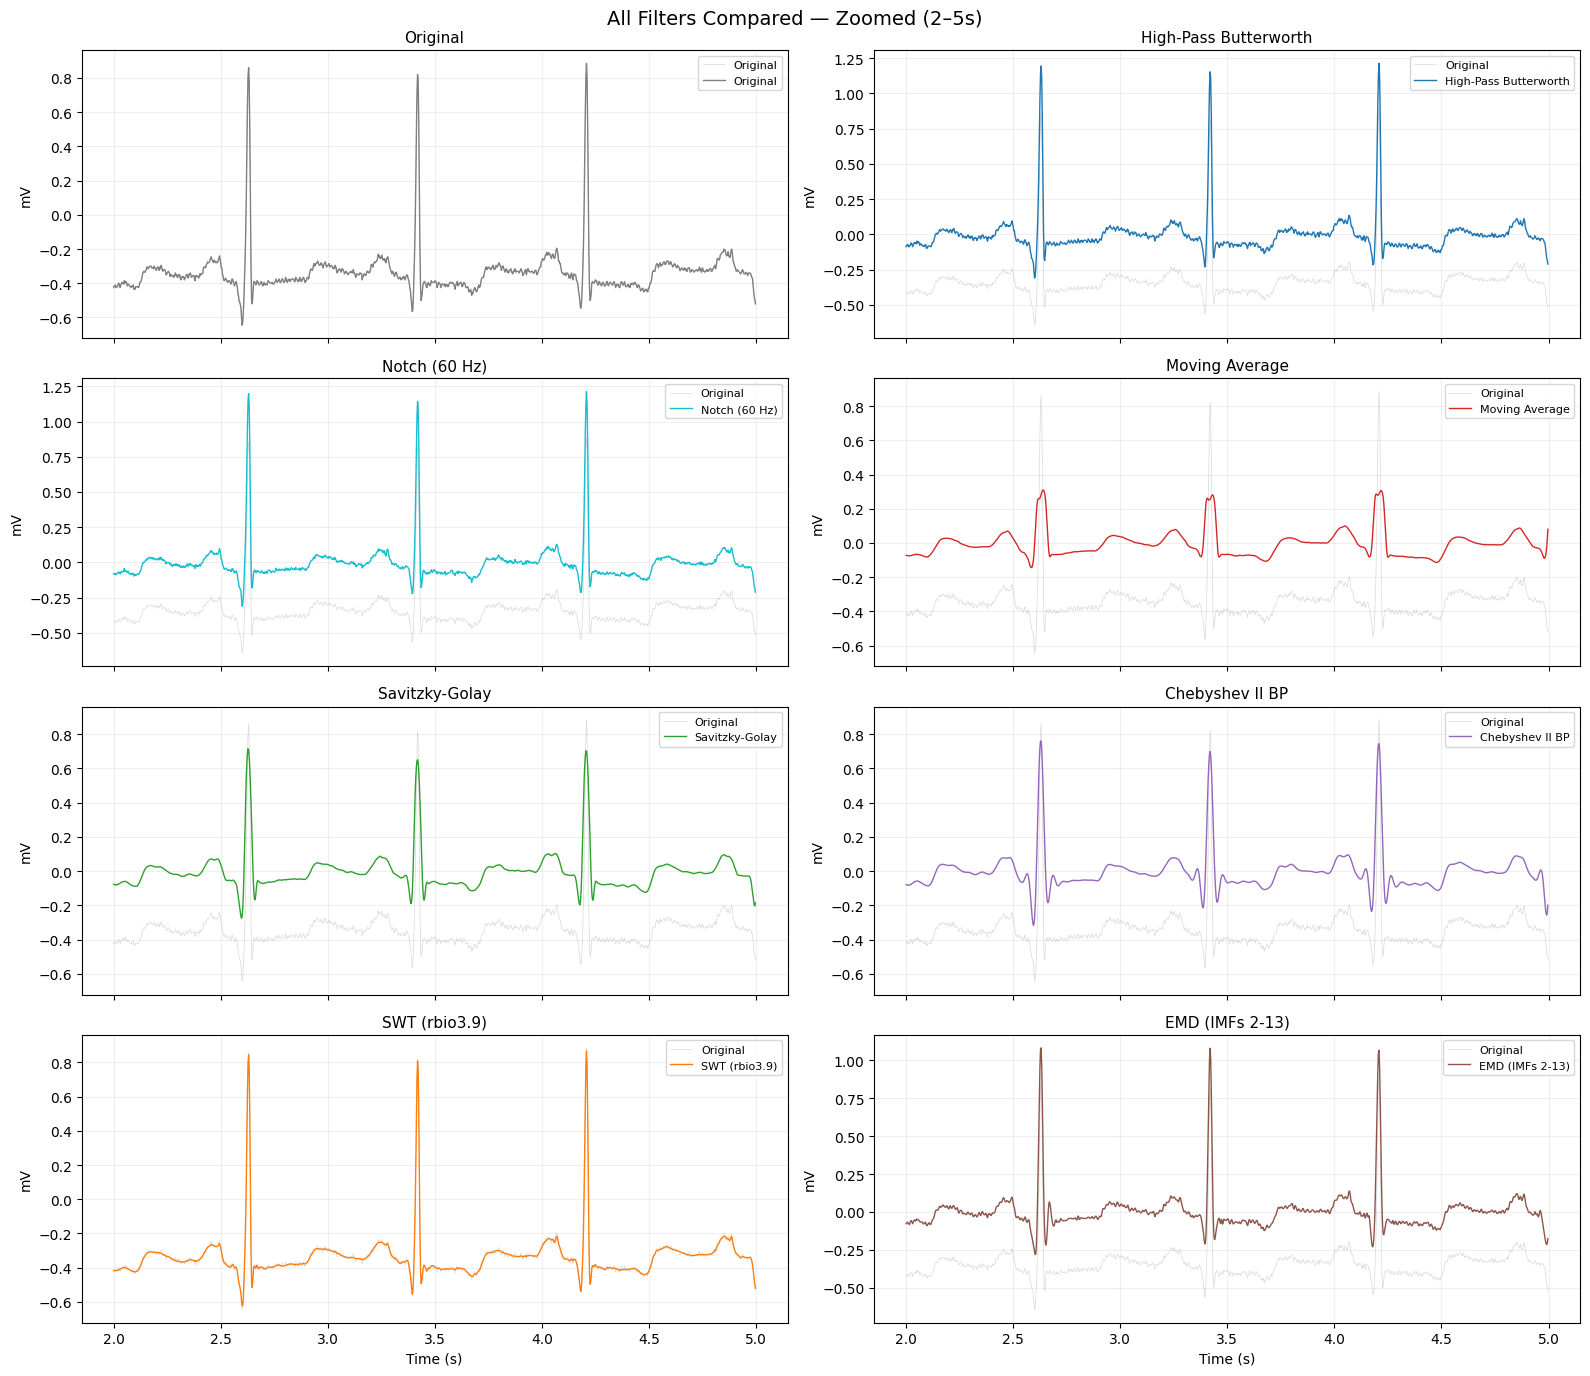

In [39]:
# Zoom into 2-5 seconds (2-3 heartbeats) for visual comparison
z_start = int(2 * fs)
z_end = int(5 * fs)
t_zoom = t_seg[z_start:z_end]

fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)

filters = [
    ('Original', seg, 'gray'),
    ('High-Pass Butterworth', ecg_hp, 'tab:blue'),
    ('Notch (60 Hz)', ecg_notch, 'tab:cyan'),
    ('Moving Average', ecg_ma, 'tab:red'),
    ('Savitzky-Golay', ecg_sgs, 'tab:green'),
    ('Chebyshev II BP', ecg_cheb, 'tab:purple'),
    ('SWT (rbio3.9)', ecg_swt, 'tab:orange'),
    ('EMD (IMFs 2-13)', ecg_emd, 'tab:brown'),
]

for idx, (name, sig, color) in enumerate(filters):
    ax = axes[idx // 2][idx % 2]
    ax.plot(t_zoom, seg[z_start:z_end], alpha=0.3, linewidth=0.5, color='gray', label='Original')
    ax.plot(t_zoom, sig[z_start:z_end], linewidth=1, color=color, label=name)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('mV')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)

axes[3][0].set_xlabel('Time (s)')
axes[3][1].set_xlabel('Time (s)')
fig.suptitle('All Filters Compared — Zoomed (2–5s)', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusions

| Rank | Filter | Best For |
|------|--------|----------|
| 🥇 | **SWT (rbio3.9, L5, 0.5)** | Overall best — highest fidelity, lowest distortion, automatic thresholding |
| 🥈 | **Savitzky-Golay** | Quick smoothing with good peak preservation |
| 🥉 | **High-Pass Butterworth** | Essential first step — baseline wander removal |
| 4 | **EMD** | Adaptive decomposition, but inconsistent and hard to tune |
| 5 | **Chebyshev II** | Sharp frequency boundaries, good as all-in-one bandpass |
| 6 | **Notch** | Surgical PLI removal — minimal effect on this clean recording |
| 7 | **Moving Average** | Avoid for ECG — destroys QRS morphology |

**Key takeaways:**
- SWT is the clear winner, matching the paper's findings
- Simpler filters (HP + Notch) are still essential as preprocessing steps
- Moving Average should be avoided when morphology preservation matters
- EMD is powerful in theory but less reliable in practice due to mode mixing

**Recommended preprocessing pipeline:**
High-Pass (0.5 Hz) → Notch (50/60 Hz) → SWT denoising

## Phase 5: Full Pipeline — All 48 Records

### Step 1: Load and Filter All Records
We apply our winning filter chain: **High-Pass (0.5 Hz) → Notch (60 Hz) → SWT denoising**
on the MLII channel of every record.

In [22]:
import warnings
warnings.filterwarnings('ignore')

# All MIT-BIH record numbers
record_nums = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

# Filter design (same as before)
sos_hp = signal.butter(4, 0.5, btype='highpass', fs=360, output='sos')
b_notch, a_notch = signal.iirnotch(60.0, 30.0, 360)

def apply_swt_denoise(sig, wavelet='rbio3.9', level=5, thresh_scale=0.5):
    """Apply SWT denoising to a signal."""
    # Pad to required length
    pad_len = int(np.ceil(len(sig) / (2**level))) * (2**level) - len(sig)
    sig_padded = np.pad(sig, (0, pad_len), mode='symmetric')
    
    coeffs = pywt.swt(sig_padded, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1][1])) / 0.6745
    threshold = thresh_scale * sigma * np.sqrt(2 * np.log(len(sig_padded)))
    
    coeffs_thresh = [(cA, pywt.threshold(cD, threshold, mode='soft')) for cA, cD in coeffs]
    reconstructed = pywt.iswt(coeffs_thresh, wavelet)
    return reconstructed[:len(sig)]

def full_filter_pipeline(sig, fs=360):
    """HP → Notch → SWT"""
    sig = signal.sosfiltfilt(sos_hp, sig)
    sig = signal.filtfilt(b_notch, a_notch, sig)
    sig = apply_swt_denoise(sig)
    return sig

# Process all records
all_data = {}
skipped = []

for rec_num in record_nums:
    try:
        record = wfdb.rdrecord(f'{DATA_PATH}/{rec_num}')
        annotation = wfdb.rdann(f'{DATA_PATH}/{rec_num}', 'atr')
        
        # Find MLII channel
        if 'MLII' in record.sig_name:
            mlii_idx = record.sig_name.index('MLII')
        else:
            skipped.append((rec_num, record.sig_name))
            continue
        
        raw = record.p_signal[:, mlii_idx]
        filtered = full_filter_pipeline(raw, record.fs)
        
        all_data[rec_num] = {
            'raw': raw,
            'filtered': filtered,
            'annotations': annotation,
            'fs': record.fs
        }
        print(f'✓ Record {rec_num} processed ({len(raw)} samples)')
        
    except Exception as e:
        skipped.append((rec_num, str(e)))

print(f'\n✅ Processed: {len(all_data)} records')
if skipped:
    print(f'⚠️ Skipped: {skipped}')

✓ Record 100 processed (650000 samples)
✓ Record 101 processed (650000 samples)
✓ Record 103 processed (650000 samples)
✓ Record 105 processed (650000 samples)
✓ Record 106 processed (650000 samples)
✓ Record 107 processed (650000 samples)
✓ Record 108 processed (650000 samples)
✓ Record 109 processed (650000 samples)
✓ Record 111 processed (650000 samples)
✓ Record 112 processed (650000 samples)
✓ Record 113 processed (650000 samples)
✓ Record 114 processed (650000 samples)
✓ Record 115 processed (650000 samples)
✓ Record 116 processed (650000 samples)
✓ Record 117 processed (650000 samples)
✓ Record 118 processed (650000 samples)
✓ Record 119 processed (650000 samples)
✓ Record 121 processed (650000 samples)
✓ Record 122 processed (650000 samples)
✓ Record 123 processed (650000 samples)
✓ Record 124 processed (650000 samples)
✓ Record 200 processed (650000 samples)
✓ Record 201 processed (650000 samples)
✓ Record 202 processed (650000 samples)
✓ Record 203 processed (650000 samples)


### Step 2: Beat Segmentation

We use the annotation file to locate each heartbeat's R-peak, then extract a fixed-length 
window around it. A common choice is **250 samples** (about 0.7 seconds at 360 Hz), 
which captures one full P-QRS-T complex regardless of heart rate.

We also map the annotation symbols to a simplified label set.

In [23]:
# MIT-BIH annotation symbols → grouped labels
# AAMI standard grouping (widely used in literature)
label_map = {
    'N': 'N',  # Normal
    'L': 'N',  # Left bundle branch block (considered normal-ish)
    'R': 'N',  # Right bundle branch block
    'e': 'N',  # Atrial escape
    'j': 'N',  # Nodal escape
    'A': 'S',  # Atrial premature
    'a': 'S',  # Aberrated atrial premature
    'J': 'S',  # Nodal premature
    'S': 'S',  # Supraventricular premature
    'V': 'V',  # Premature ventricular contraction
    'E': 'V',  # Ventricular escape
    'F': 'F',  # Fusion of ventricular and normal
    '/': 'Q',  # Paced beat
    'f': 'Q',  # Fusion of paced and normal
    'Q': 'Q',  # Unclassifiable
}

# Non-beat annotations to skip (rhythm markers, comments, etc.)
non_beat = {'+', '~', '|', '!', '[', ']', '"', 'x'}

WINDOW = 250  # samples (~694 ms at 360 Hz)
HALF = WINDOW // 2

beats = []
labels = []
record_ids = []

for rec_num, data in all_data.items():
    sig = data['filtered']
    ann = data['annotations']
    
    for i, (sample, symbol) in enumerate(zip(ann.sample, ann.symbol)):
        # Skip non-beat annotations
        if symbol in non_beat or symbol not in label_map:
            continue
        
        # Skip beats too close to signal edges
        if sample - HALF < 0 or sample + HALF > len(sig):
            continue
        
        beat = sig[sample - HALF : sample + HALF]
        
        if len(beat) == WINDOW:
            beats.append(beat)
            labels.append(label_map[symbol])
            record_ids.append(rec_num)

X = np.array(beats)
y = np.array(labels)
record_ids = np.array(record_ids)

print(f"Total beats extracted: {X.shape[0]}")
print(f"Beat shape: {X.shape[1]} samples ({X.shape[1]/360*1000:.0f} ms)")
print(f"\nClass distribution:")
for cls in ['N', 'S', 'V', 'F', 'Q']:
    count = np.sum(y == cls)
    if count > 0:
        print(f"  {cls}: {count} ({100*count/len(y):.1f}%)")

Total beats extracted: 105039
Beat shape: 250 samples (694 ms)

Class distribution:
  N: 90333 (86.0%)
  S: 2781 (2.6%)
  V: 7229 (6.9%)
  F: 802 (0.8%)
  Q: 3894 (3.7%)


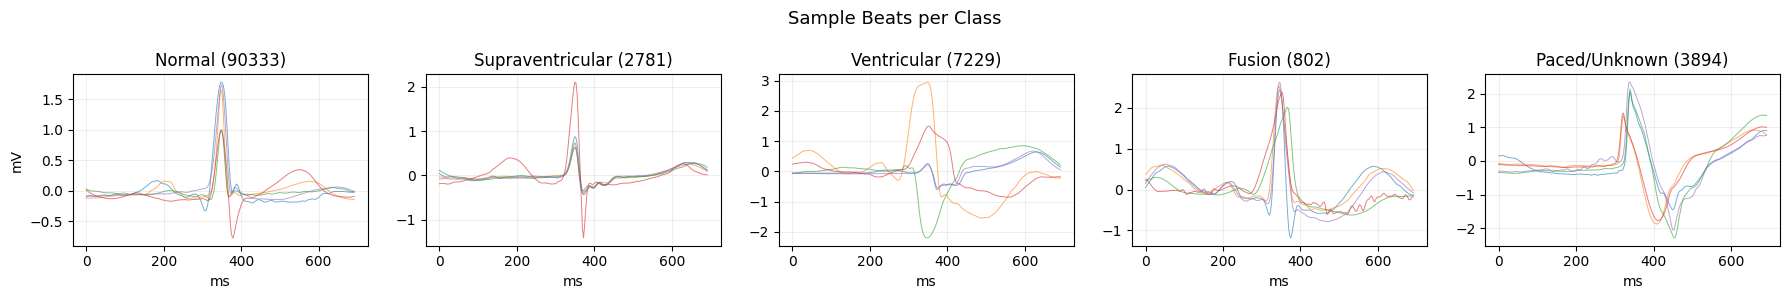

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
t_beat = np.arange(WINDOW) / 360 * 1000  # ms

class_names = {'N': 'Normal', 'S': 'Supraventricular', 'V': 'Ventricular', 'F': 'Fusion', 'Q': 'Paced/Unknown'}

for i, cls in enumerate(['N', 'S', 'V', 'F', 'Q']):
    mask = y == cls
    if mask.sum() == 0:
        axes[i].set_title(f'{class_names[cls]}\n(none)')
        continue
    # Plot 5 random examples
    indices = np.where(mask)[0]
    samples = np.random.choice(indices, min(5, len(indices)), replace=False)
    for idx in samples:
        axes[i].plot(t_beat, X[idx], linewidth=0.7, alpha=0.6)
    axes[i].set_title(f'{class_names[cls]} ({mask.sum()})')
    axes[i].set_xlabel('ms')
    axes[i].grid(True, alpha=0.2)

axes[0].set_ylabel('mV')
fig.suptitle('Sample Beats per Class', fontsize=13)
plt.tight_layout()
plt.show()

### Step 3: Normalization

Each record was recorded from a different patient with different electrode placement, body size, 
and signal amplitude. A beat from patient A might range from -0.5 to 1.0 mV while patient B 
ranges from -0.2 to 0.4 mV. Without normalization, the model learns amplitude differences 
between patients instead of shape differences between beat types.

**Z-score normalization (per beat):** subtract the mean, divide by std. 
Each beat ends up with mean ≈ 0 and std ≈ 1. The model now focuses purely on *morphology* (shape).

Before normalization — Beat 0: mean=0.0021, std=0.1968
After normalization  — Beat 0: mean=-0.000000, std=1.000000


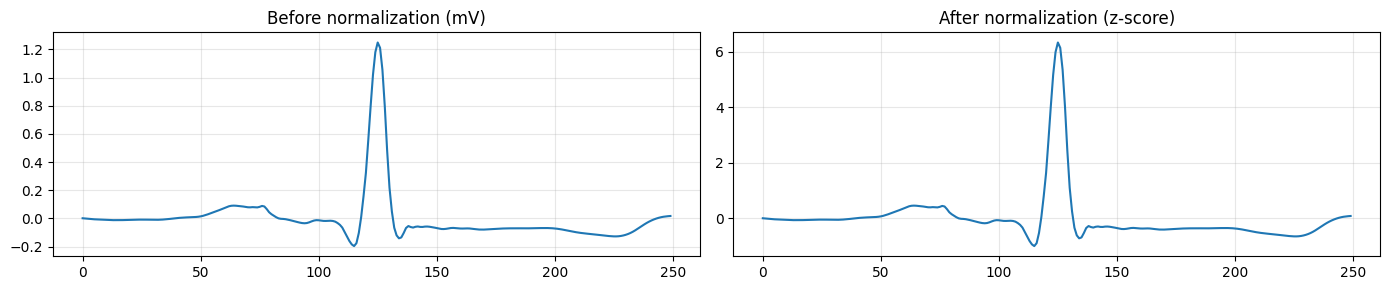

In [25]:
# Z-score normalization — per beat
X_norm = np.zeros_like(X)
for i in range(len(X)):
    mean = X[i].mean()
    std = X[i].std()
    if std > 0:
        X_norm[i] = (X[i] - mean) / std
    else:
        X_norm[i] = X[i] - mean  # flat signal edge case

print(f"Before normalization — Beat 0: mean={X[0].mean():.4f}, std={X[0].std():.4f}")
print(f"After normalization  — Beat 0: mean={X_norm[0].mean():.6f}, std={X_norm[0].std():.6f}")

# Verify visually
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].plot(X[0])
axes[0].set_title('Before normalization (mV)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(X_norm[0])
axes[1].set_title('After normalization (z-score)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 4: Patient-Level Train/Test Split

**Critical rule:** Records 201 and 202 are from the same patient. If one goes to training 
and the other to testing, the model has already "seen" that heart — this is **data leakage**.

We split by **patient (record)**, not by beat. All beats from one record stay together. 
Standard split: 70% train, 15% validation, 15% test.

In [36]:
from sklearn.model_selection import GroupShuffleSplit

# Map records to patient IDs (201 and 202 are the same patient)
patient_map = {rec: rec for rec in np.unique(record_ids)}
patient_map['202'] = '201'
patient_ids = np.array([patient_map[r] for r in record_ids])

# Single split: 80% train, 20% test
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=10
                        )
train_idx, test_idx = next(gss.split(X_norm, y, groups=patient_ids))

X_train, y_train = X_norm[train_idx], y[train_idx]
X_test, y_test = X_norm[test_idx], y[test_idx]

print(f"Train: {len(X_train)} beats ({100*len(X_train)/len(X_norm):.1f}%)")
print(f"Test:  {len(X_test)} beats ({100*len(X_test)/len(X_norm):.1f}%)")

# Verify no patient leakage
train_patients = set(patient_ids[train_idx])
test_patients = set(patient_ids[test_idx])
print(f"\nTrain patients: {len(train_patients)}")
print(f"Test patients:  {len(test_patients)}")
print(f"Overlap train∩test: {train_patients & test_patients}")

# Class distribution per split
print("\nClass distribution:")
for split_name, split_y in [('Train', y_train), ('Test', y_test)]:
    print(f"  {split_name}:")
    for cls in ['N', 'S', 'V', 'F', 'Q']:
        count = np.sum(split_y == cls)
        print(f"    {cls}: {count} ({100*count/len(split_y):.1f}%)")

Train: 83736 beats (79.7%)
Test:  21303 beats (20.3%)

Train patients: 36
Test patients:  9
Overlap train∩test: set()

Class distribution:
  Train:
    N: 72263 (86.3%)
    S: 2707 (3.2%)
    V: 6250 (7.5%)
    F: 433 (0.5%)
    Q: 2083 (2.5%)
  Test:
    N: 18070 (84.8%)
    S: 74 (0.3%)
    V: 979 (4.6%)
    F: 369 (1.7%)
    Q: 1811 (8.5%)


In [37]:
# Save as .npz for easy loading later
np.savez('mitbih_preprocessed.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)

print("✅ Saved to mitbih_preprocessed.npz")
print(f"   File contains: X_train, y_train, X_val, y_val, X_test, y_test")
print(f"   Total size: {X_train.nbytes + X_val.nbytes + X_test.nbytes:.1f} bytes")

# How to load later:
# data = np.load('mitbih_preprocessed.npz')
# X_train, y_train = data['X_train'], data['y_train']

✅ Saved to mitbih_preprocessed.npz
   File contains: X_train, y_train, X_val, y_val, X_test, y_test
   Total size: 242476000.0 bytes
